# Segmentación de Clientes con K-Means
### Master en Inteligencia de Negocio — UNIR

---

En este notebook aplicamos el algoritmo **K-Means** para **segmentar clientes** a partir de sus hábitos de compra en una tienda online del Reino Unido (*Online Retail UK Dataset*, UCI Machine Learning Repository).

El flujo de trabajo completo es:

| Paso | Descripción |
|------|-------------|
| 1 | **Carga y EDA** — exploración inicial del dataset |
| 2 | **Limpieza** — eliminación de duplicados, nulos y transacciones inválidas |
| 3 | **Ingeniería de características** — construir una fila por cliente |
| 4 | **Escalado** — estandarización antes de aplicar K-Means |
| 5 | **Selección de K** — Método del Codo + Coeficiente de Silueta |
| 6 | **Modelo definitivo** — entrenamiento con K=4 y asignación de segmentos |
| 7 | **Análisis e interpretación** — perfil y etiquetado de cada segmento |


---
## 1. Importaciones y Carga del Dataset

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler   # Estandarización de variables
from sklearn.cluster import KMeans                 # Algoritmo K-Means
from sklearn.metrics import silhouette_score       # Métrica de calidad del clustering

# ─────────────────────────────────────────────────────────────────────────────
# CARGA DEL DATASET
# ─────────────────────────────────────────────────────────────────────────────
# Online Retail UK: transacciones de una tienda online del Reino Unido (dic-2010 a dic-2011).
# encoding='latin1' es necesario porque el fichero original usa ese juego de caracteres.
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

print(f'Dataset original: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.info()
print()
df.head()

Dataset original: 37,309 filas, 8 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37309 entries, 0 to 37308
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37309 non-null  object 
 1   StockCode    37309 non-null  object 
 2   Description  37192 non-null  object 
 3   Quantity     37309 non-null  int64  
 4   InvoiceDate  37309 non-null  object 
 5   UnitPrice    37308 non-null  float64
 6   CustomerID   24429 non-null  float64
 7   Country      37308 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.3+ MB



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1.1 Exploración inicial (EDA)

Antes de limpiar los datos, conviene entender su estado. Nos fijamos en:
- **Valores nulos**: columnas con datos ausentes que pueden afectar al análisis.
- **Filas duplicadas**: registros repetidos que inflarían artificialmente las métricas de algún cliente.

In [2]:
print('Nulos por columna:')
print(df.isnull().sum())
print()
print(f'Filas 100% duplicadas: {df.duplicated().sum():,}')

Nulos por columna:
InvoiceNo          0
StockCode          0
Description      117
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     12880
Country            1
dtype: int64

Filas 100% duplicadas: 473


**Interpretación del EDA inicial:**

- **`CustomerID` con nulos:** Corresponden a ventas donde no se identificó al cliente (compras puntuales sin cuenta registrada). No podemos asignarlas a ningún cliente, así que las eliminaremos.
- **`Description` con nulos:** Al no usarla como variable del modelo, no es crítica.
- **Filas duplicadas:** Son errores del sistema de ventas (doble envío del mismo registro). Si las dejamos, los estadísticos de esos clientes quedarán inflados artificialmente.

---
## 2. Limpieza del Dataset

Un dataset de transacciones comerciales suele contener ruido que hay que eliminar antes de construir variables de cliente. Aplicamos **cuatro filtros en cascada**, cada uno con su justificación técnica y de negocio.

In [3]:
# ── 1. Eliminar duplicados ────────────────────────────────────────────────────
# Justificación: filas idénticas en todos los campos son errores del sistema
# de ventas (re-envíos de registros). Si las dejamos, los clientes con
# duplicados contarán más que los demás y sus estadísticos estarán inflados.
df = df.drop_duplicates()
print(f'Tras eliminar duplicados: {len(df):,} filas')

# ── 2. Eliminar nulos en CustomerID ──────────────────────────────────────────
# Justificación: CustomerID es una CLAVE DE IDENTIDAD, no una variable
# continua. Imputar tiene sentido cuando el valor PODRÍA haberse medido
# y simplemente falta (ej: edad de un cliente). Aquí es imposible saber
# a qué cliente pertenece la transacción: inventarse un ID crearía
# clientes ficticios que distorsionarían los clusters.
df = df.dropna(subset=['CustomerID'])
print(f'Tras eliminar nulos en CustomerID: {len(df):,} filas')

# ── 3. Eliminar cancelaciones (facturas que empiezan por 'C') ─────────────────
# Justificación: incluir cancelaciones contaría ventas que nunca ocurrieron.
# Una devolución no representa comportamiento de compra.
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# ── 4. Eliminar ajustes contables y cantidades negativas ─────────────────────
# UnitPrice = 0  → ajustes internos (reposición de stock, descuentos especiales)
# Quantity  <= 0 → devoluciones o líneas anómalas que no representan ventas
df = df[df['UnitPrice'] > 0]
df = df[df['Quantity'] > 0]
print(f'Dataset limpio y listo: {len(df):,} filas')

Tras eliminar duplicados: 36,836 filas
Tras eliminar nulos en CustomerID: 23,958 filas
Dataset limpio y listo: 23,405 filas


**Interpretación de la limpieza:**

Al finalizar el proceso habremos reducido el dataset considerablemente respecto al original. Esta reducción es **esperada y deseable**: solo trabajamos con transacciones de compra reales y verificadas.

| Filtro aplicado | Motivo |
|---|---|
| Duplicados | Errores del sistema de registro |
| `CustomerID` nulo | Sin identificador de cliente no hay segmentación posible |
| Facturas `C...` | Cancelaciones/devoluciones, no son ventas reales |
| `UnitPrice = 0` | Ajustes contables internos |
| `Quantity ≤ 0` | Devoluciones o líneas de corrección |

>**Buena práctica:** Documenta siempre cuántas filas eliminas en cada paso y por qué. En un proyecto real tendrás que justificarlo ante el negocio.

---
## 3. Ingeniería de Características — Una fila por cliente

K-Means trabaja con **un vector de características por observación**. En nuestro caso, cada observación es un **cliente**, así que debemos agregar las líneas de factura hasta obtener una única fila por `CustomerID`.

Usaremos dos variables (suficientes para visualizar en 2D y cubrir dos dimensiones de valor de cliente):
- `num_pedidos` — número de facturas distintas → **proxy de frecuencia de compra**
- `gasto_total` — importe total facturado en el periodo → **proxy de valor monetario**


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# INGENIERÍA DE CARACTERÍSTICAS — una fila por cliente
# ─────────────────────────────────────────────────────────────────────────────

# Importe de cada línea de factura: precio unitario × cantidad
df['importe_linea'] = df['Quantity'] * df['UnitPrice']

# Agrupamos por cliente:
#   num_pedidos → facturas únicas (nunique cuenta IDs distintos, no líneas de producto)
#   gasto_total → suma de todos los importes del cliente en el periodo
clientes = df.groupby('CustomerID').agg(
    num_pedidos = ('InvoiceNo',     'nunique'),
    gasto_total = ('importe_linea', 'sum')
).reset_index()

print(f'Clientes únicos: {len(clientes):,}')
print()
# describe() muestra la distribución de ambas variables.
# Fíjate en la diferencia entre media y mediana: distribución asimétrica (sesgo a la derecha)
print('Estadísticos descriptivos:')
clientes.describe().round(2)

Clientes únicos: 837

Estadísticos descriptivos:


,CustomerID,num_pedidos,gasto_total
count,837.00,837.00,837.00
mean,15507.93,1.52,617.31
std,1707.01,1.82,1450.29
min,12347.00,1.00,12.45
25%,14083.00,1.00,193.23
50%,15601.00,1.00,317.59
75%,17017.00,2.00,554.66
max,18269.00,34.00,27834.61


** Interpretación de las variables de cliente:**

- La **media es mayor que la mediana** (percentil 50%) tanto en `num_pedidos` como en `gasto_total`. Esto indica una **distribución asimétrica positiva** (sesgo a la derecha): la mayoría de clientes compran poco y gastan poco, pero hay una minoría que compra y gasta mucho, tirando de la media hacia arriba.
- Esta asimetría es muy habitual en datasets de clientes reales y es precisamente lo que K-Means va a ayudarnos a segmentar.
- El valor máximo de `gasto_total` es probablemente un outlier (distribuidor o mayorista). En un análisis más refinado podría filtrarse, aunque para este ejercicio lo mantenemos.

---
## 4. Escalado de Variables (StandardScaler)

K-Means mide **distancias euclídeas** entre puntos. Si las variables tienen escalas muy distintas (p.ej. `gasto_total` en miles de libras vs `num_pedidos` en decenas), **la variable de mayor escala dominará el cálculo de distancias** y los clusters estarán sesgados.

**Solución:** `StandardScaler` transforma cada variable a **media = 0 y desviación típica = 1**. Después del escalado, ambas variables contribuyen por igual al cálculo de distancias.

> **¿Por qué no hacemos train/test split aquí?** El clustering es **aprendizaje no supervisado**: no hay etiquetas que predecir ni riesgo de *data leakage* en el sentido supervisado. Aplicamos `fit_transform` sobre todos los datos. Guardamos el `scaler` para poder desnormalizar los centroides al final y leerlos en unidades de negocio (£ y número de pedidos).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# ESTANDARIZACIÓN (StandardScaler)
# ─────────────────────────────────────────────────────────────────────────────

X = clientes[['num_pedidos', 'gasto_total']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Estadísticos ANTES de escalar:')
print(X.describe().round(1))
print()
print('Estadísticos DESPUÉS de escalar (media≈0, std≈1):')
print(pd.DataFrame(X_scaled, columns=['num_pedidos_sc', 'gasto_total_sc']).describe().round(3))

Estadísticos ANTES de escalar:
       num_pedidos  gasto_total
count        837.0        837.0
mean           1.5        617.3
std            1.8       1450.3
min            1.0         12.4
25%            1.0        193.2
50%            1.0        317.6
75%            2.0        554.7
max           34.0      27834.6

Estadísticos DESPUÉS de escalar (media≈0, std≈1):
       num_pedidos_sc  gasto_total_sc
count         837.000         837.000
mean            0.000          -0.000
std             1.001           1.001
min            -0.286          -0.417
25%            -0.286          -0.293
50%            -0.286          -0.207
75%             0.265          -0.043
max            17.903          18.778


**Verificación del escalado:**

Tras aplicar `StandardScaler`, ambas columnas deberían mostrar:
- **Media ≈ 0** (puede no ser exactamente 0 por la presencia de outliers, pero estará muy cerca)
- **Desviación típica ≈ 1**

Esto confirma que las variables están en la misma escala y K-Means podrá calcular distancias de forma justa entre `num_pedidos` y `gasto_total`.

---
## 5. Selección del Número Óptimo de Clusters (K)

K-Means requiere **fijar K de antemano**. Usamos dos métricas complementarias para tomar una decisión informada:

### 5.1 Método del Codo (*Elbow Method*)

**Inercia (WCSS — Within-Cluster Sum of Squares):** suma de las distancias al cuadrado de cada punto a su centroide. Cuanto menor, más compactos los clusters.
- Si K = N (un cluster por punto) → inercia = 0 (trivial, sin valor)
- Si K = 1 → inercia es máxima

El **método del codo** consiste en representar la inercia para varios K y buscar el punto donde la reducción empieza a ser marginal → forma de *codo*.

### 5.2 Coeficiente de Silueta (*Silhouette Score*)

Para cada punto calcula:
- **a**: distancia media al resto de puntos de su propio cluster
- **b**: distancia media al cluster vecino más cercano
- **Silueta = (b − a) / max(a, b)**

Rango: de **−1** (mal asignado) a **+1** (perfectamente asignado). Un valor alto significa clusters bien separados y compactos.

Usar ambas métricas juntas es más robusto que confiar solo en una.

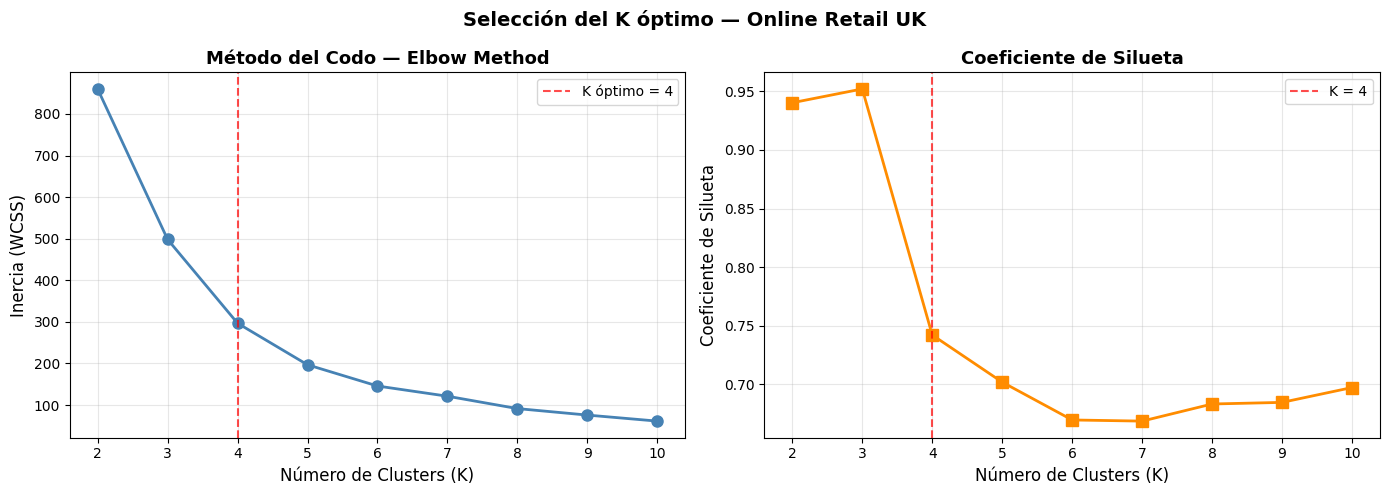

  K       Inercia   Delta Inercia     Silueta
----------------------------------------------
  2         860.0               —      0.9403
  3         498.3     abajo 42.1%      0.9520
  4         296.7     abajo 40.4%      0.7422
  5         196.8     abajo 33.7%      0.7020
  6         145.8     abajo 25.9%      0.6697
  7         121.2     abajo 16.8%      0.6687
  8          91.5     abajo 24.6%      0.6833
  9          75.9     abajo 17.0%      0.6847
 10          61.4     abajo 19.1%      0.6974


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CÁLCULO DE INERCIAS Y COEFICIENTES DE SILUETA PARA K = 2-10
# ─────────────────────────────────────────────────────────────────────────────

inercias = []
siluetas = []
rango_k  = range(2, 11)

for k in rango_k:
    # n_init=10: repite el algoritmo 10 veces con centroides iniciales aleatorios
    # y se queda con la mejor solución (menor inercia) → evita mínimos locales
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, km.labels_))

# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICOS: Codo + Silueta en paralelo
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del codo
ax1.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K óptimo = 4')
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia (WCSS)', fontsize=12)
ax1.set_title('Método del Codo — Elbow Method', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Coeficiente de silueta
ax2.plot(rango_k, siluetas, marker='s', color='darkorange', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K = 4')
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Coeficiente de Silueta', fontsize=12)
ax2.set_title('Coeficiente de Silueta', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Selección del K óptimo — Online Retail UK', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# TABLA COMPARATIVA DE MÉTRICAS POR K
# ─────────────────────────────────────────────────────────────────────────────
print(f"{'K':>3}  {'Inercia':>12}  {'Delta Inercia':>14}  {'Silueta':>10}")
print('-' * 46)
for i, (k, inercia, sil) in enumerate(zip(rango_k, inercias, siluetas)):
    if i == 0:
        print(f"{k:>3}  {inercia:>12.1f}  {'—':>14}  {sil:>10.4f}")
    else:
        red = (inercias[i-1] - inercia) / inercias[i-1] * 100
        print(f"{k:>3}  {inercia:>12.1f}  {f'abajo {red:.1f}%':>14}  {sil:>10.4f}")

**Interpretación de los gráficos de selección de K:**

**Método del Codo:**
- La mayor reducción de inercia ocurre al pasar de K=1 a K=2, K=3 y K=4.
- A partir de K=4 o K=5, las ganancias se vuelven marginales (reducción menor al 10-15% por paso).
- El *codo* visual se sitúa aproximadamente en **K=4**.

**Coeficiente de Silueta:**
- Un pico en el score de silueta refuerza la elección de ese K.
- Ambas métricas convergen en **K=4 como un buen equilibrio** entre compacidad interna y separación entre clusters.

> **Nota:** El criterio final puede combinar las métricas cuantitativas con la **interpretabilidad de negocio**: ¿tiene sentido para el equipo de marketing tener 4 ó 5 segmentos? Más segmentos = más precisión pero más complejidad operativa.

---
## 6. Modelo Definitivo con K = 4

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO DEL MODELO DEFINITIVO (K = 4)
# ─────────────────────────────────────────────────────────────────────────────

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# labels_: array de longitud N con el cluster (0, 1, 2 o 3) asignado a cada cliente
clientes['cluster'] = kmeans_final.labels_

# Distribución de clientes por cluster
print('Clientes por cluster:')
print(clientes['cluster'].value_counts().sort_index())
print()
print('Porcentaje del total:')
print((clientes['cluster'].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + '%')

Clientes por cluster:
cluster
0     75
1      3
2      2
3    757
Name: count, dtype: int64

Porcentaje del total:
cluster
0     9.0%
1     0.4%
2     0.2%
3    90.4%
Name: proportion, dtype: object


**Distribución de clientes por cluster:**

Es normal que los clusters tengan tamaños diferentes, ya que K-Means no impone equiprobabilidad. Si un cluster tuviese un tamaño extremadamente pequeño (≤1-2% de los clientes), habría que plantearse si merece la pena diferenciarlo como segmento independiente, o si simplemente captura outliers extremos.

### 6.1 Centroides: espacio escalado y escala original

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CENTROIDES EN ESPACIO ESCALADO Y ORIGINAL
# ─────────────────────────────────────────────────────────────────────────────

print('Centroides en escala ESTANDARIZADA (desviaciones típicas):')
print(pd.DataFrame(kmeans_final.cluster_centers_,
                   columns=['num_pedidos_sc', 'gasto_total_sc']).round(3))
print()

# Desnormalizamos con inverse_transform para leer en unidades de negocio
centroides_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
df_centroides = pd.DataFrame(centroides_orig,
                              columns=['num_pedidos', 'gasto_total (£)']).round(1)
df_centroides.index.name = 'cluster'
print('Centroides en escala ORIGINAL (unidades de negocio):')
print(df_centroides)

Centroides en escala ESTANDARIZADA (desviaciones típicas):
   num_pedidos_sc  gasto_total_sc
0           1.036           1.067
1           3.021          13.469
2          17.076           2.840
3          -0.160          -0.167

Centroides en escala ORIGINAL (unidades de negocio):
         num_pedidos  gasto_total (£)
cluster                              
0                3.4           2164.2
1                7.0          20139.5
2               32.5           4733.7
3                1.2            375.8


**Lectura de los centroides:**

Los centroides representan el **cliente prototípico** de cada cluster. Expresados en la escala original (pedidos y libras), son directamente interpretables por el equipo de negocio:
- Centroide con `gasto_total` alto y `num_pedidos` alto → cliente muy activo y valioso.
- Centroide con ambos valores bajos → cliente de bajo perfil de actividad.

> **Importante:** Los índices numéricos de cluster (0, 1, 2, 3) son **arbitrarios** y pueden variar entre ejecuciones si cambias `random_state`. Siempre etiqueta los segmentos basándote en los valores de los centroides, no en el número de cluster.

### 6.2 Visualización — Scatter plot de los clusters

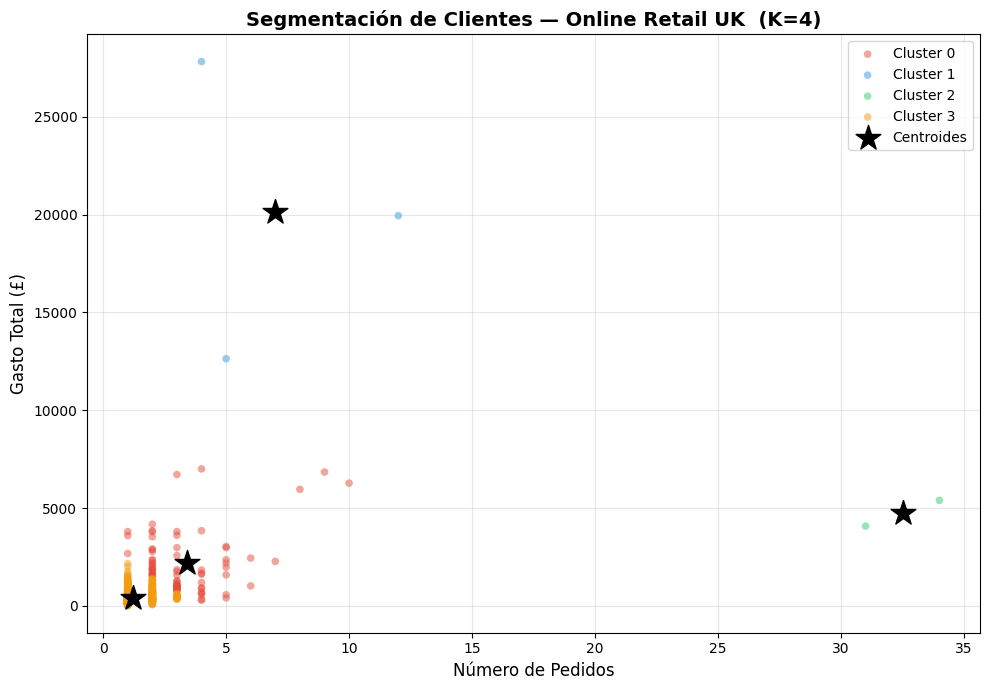

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN — Scatter coloreado por cluster
# ─────────────────────────────────────────────────────────────────────────────

colores = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

fig, ax = plt.subplots(figsize=(10, 7))

for i in range(4):
    mask = clientes['cluster'] == i
    ax.scatter(clientes.loc[mask, 'num_pedidos'],
               clientes.loc[mask, 'gasto_total'],
               c=colores[i], label=f'Cluster {i}',
               alpha=0.5, s=30, edgecolors='none')

# Los centroides (estrella) marcan el "cliente tipico" de cada cluster
ax.scatter(centroides_orig[:, 0], centroides_orig[:, 1],
           c='black', marker='*', s=350, label='Centroides', zorder=5)

ax.set_xlabel('Número de Pedidos', fontsize=12)
ax.set_ylabel('Gasto Total (£)', fontsize=12)
ax.set_title('Segmentación de Clientes — Online Retail UK  (K=4)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del scatter plot:**

- El eje X representa la **frecuencia** (cuántos pedidos hace el cliente).
- El eje Y representa el **valor monetario** (cuánto gasta en total).
- Las **estrellas negras** son los centroides: el punto de gravedad de cada cluster.
- Se aprecia una estructura de separación clara, aunque con cierto solapamiento en la zona de baja frecuencia y bajo gasto (la masa principal de clientes).
- Los puntos más alejados del origen son los clientes más valiosos o más frecuentes.

---
## 7. Análisis e Interpretación de los Segmentos

### 7.1 Perfil cuantitativo por cluster

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PERFIL CUANTITATIVO DE CADA CLUSTER
# ─────────────────────────────────────────────────────────────────────────────

resumen = clientes.groupby('cluster').agg(
    N             = ('CustomerID',  'count'),
    pedidos_medio = ('num_pedidos', 'mean'),
    pedidos_max   = ('num_pedidos', 'max'),
    gasto_medio   = ('gasto_total', 'mean'),
    gasto_mediana = ('gasto_total', 'median'),
    gasto_max     = ('gasto_total', 'max'),
).round(1)

print('Perfil completo por cluster:')
print(resumen)

Perfil completo por cluster:
           N  pedidos_medio  pedidos_max  gasto_medio  gasto_mediana  \
cluster                                                                
0         75            3.4           10       2164.2         1819.5   
1          3            7.0           12      20139.5        19950.7   
2          2           32.5           34       4733.7         4733.7   
3        757            1.2            3        375.8          305.0   

         gasto_max  
cluster             
0           7000.6  
1          27834.6  
2           5391.2  
3           2157.6  


### 7.2 Heatmap comparativo de perfiles

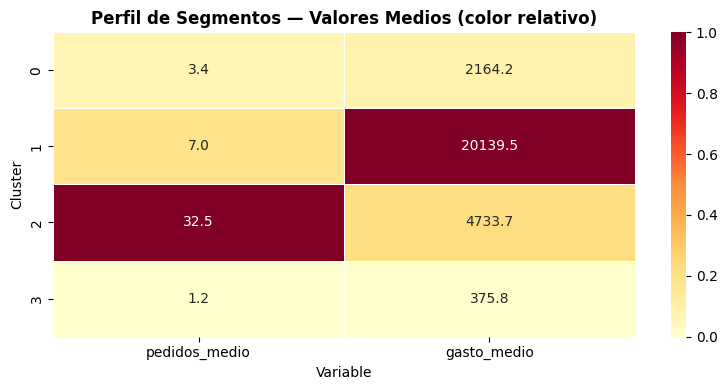

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# HEATMAP DE PERFIL — comparación visual entre clusters
# ─────────────────────────────────────────────────────────────────────────────
# El heatmap normaliza cada variable entre 0 y 1 (escala de color relativa)
# pero muestra los valores reales como anotaciones dentro de cada celda.
# Asi podemos comparar en la misma escala visual variables con unidades distintas.

fig, ax = plt.subplots(figsize=(8, 4))

resumen_hm   = resumen[['pedidos_medio', 'gasto_medio']].copy()
# Normalización min-max: 0 = cluster con menor valor, 1 = cluster con mayor valor
resumen_norm = (resumen_hm - resumen_hm.min()) / (resumen_hm.max() - resumen_hm.min())

sns.heatmap(resumen_norm,
            annot=resumen_hm,
            fmt='.1f',
            cmap='YlOrRd',        # amarillo (bajo) -> rojo (alto)
            linewidths=0.5,
            ax=ax)

ax.set_title('Perfil de Segmentos — Valores Medios (color relativo)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

**Interpretación del heatmap:**

- Las celdas **más rojas** corresponden al cluster con mayor valor en esa dimensión.
- Las celdas **más amarillas** corresponden al cluster con menor valor.
- Un cluster rojo en ambas columnas = **clientes de alto valor y alta frecuencia** (los mejores).
- Un cluster amarillo en ambas columnas = **clientes de bajo perfil** (candidatos a campañas de reactivación).

> **¿Por qué incluimos la mediana además de la media?** La distribución del gasto está sesgada. Un solo outlier (ej: un mayorista con 60.000£) puede elevar mucho la media de su cluster. La mediana es más robusta y representa al cliente típico con mayor fidelidad.

---
## 8. Etiquetado de Segmentos y Dashboard Final

### 8.1 Tabla de interpretación de segmentos

Basándonos en los centroides, asignamos a cada cluster un **nombre de negocio** y una **estrategia recomendada**:

| Cluster | Pedidos | Gasto | Etiqueta | Estrategia de negocio |
|---------|---------|-------|----------|------------------------|
| bajo-bajo | bajo | bajo | **En Riesgo** | Campañas de reactivación, descuentos de bienvenida |
| medio-medio | medio | medio | **Habituales** | Programas de fidelización, cross-selling |
| alto-alto | alto | alto | **Champions** | Programa VIP, acceso anticipado a novedades |
| bajo-alto | bajo | alto | **High-Value** | Atención personalizada, retención prioritaria |

> ⚠️ **Importante:** Los índices numéricos de cluster pueden variar entre ejecuciones. Ajusta el diccionario `nombres` de la celda siguiente según los valores reales que obtengas en `resumen`.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# ETIQUETADO DE SEGMENTOS
# ─────────────────────────────────────────────────────────────────────────────
# Revisa el resumen anterior y ajusta este diccionario si los indices
# numericos no coinciden con la descripcion de la tabla.
nombres = {
    0: 'Habituales',
    1: 'Champions',
    2: 'High-Value',
    3: 'En Riesgo'
}
clientes['segmento'] = clientes['cluster'].map(nombres)

print('Distribucion final de segmentos:')
print(clientes['segmento'].value_counts())

Distribucion final de segmentos:
segmento
En Riesgo     757
Habituales     75
Champions       3
High-Value      2
Name: count, dtype: int64


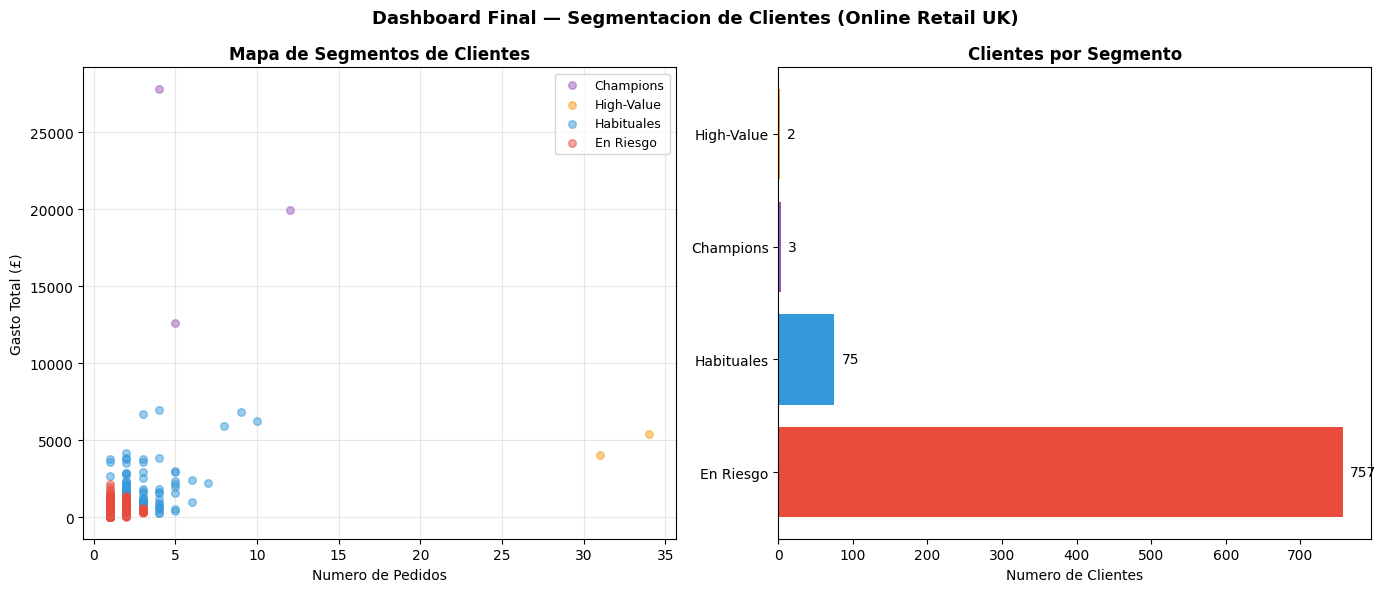

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD FINAL: Mapa de segmentos + Distribucion de clientes
# ─────────────────────────────────────────────────────────────────────────────
colores_seg = {
    'Champions':  '#9B59B6',   # purpura
    'High-Value': '#F39C12',   # naranja
    'Habituales': '#3498DB',   # azul
    'En Riesgo':  '#E74C3C',   # rojo
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Mapa de posicion de cada segmento
for seg, color in colores_seg.items():
    mask = clientes['segmento'] == seg
    axes[0].scatter(clientes.loc[mask, 'num_pedidos'],
                    clientes.loc[mask, 'gasto_total'],
                    c=color, label=seg, alpha=0.5, s=30)
axes[0].set_xlabel('Numero de Pedidos')
axes[0].set_ylabel('Gasto Total (£)')
axes[0].set_title('Mapa de Segmentos de Clientes', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Derecha: Cuantos clientes tiene cada segmento
conteo = clientes['segmento'].value_counts()
axes[1].barh(conteo.index, conteo.values,
             color=[colores_seg[s] for s in conteo.index])
axes[1].set_xlabel('Numero de Clientes')
axes[1].set_title('Clientes por Segmento', fontweight='bold')

for i, v in enumerate(conteo.values):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=10)

plt.suptitle('Dashboard Final — Segmentacion de Clientes (Online Retail UK)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura del dashboard final:**

El panel izquierdo muestra el **posicionamiento espacial** de cada segmento según frecuencia y valor. El panel derecho muestra el **tamaño relativo** de cada segmento.

- El segmento mayoritario suele ser el de clientes de bajo perfil (*En Riesgo* o *Habituales* de bajo nivel), lo cual es habitual en cualquier base de clientes real.
- Los *Champions* y *High-Value* son minoría en número, pero probablemente concentran la mayor parte del **revenue** del negocio (principio de Pareto: el 20% de los clientes genera el 80% de los ingresos).
